# PHASE 1 UNDERSTANDING

In [2]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv("/kaggle/input/datasets/austinreese/craigslist-carstrucks-data/vehicles.csv")

In [4]:
len(df.columns.tolist())
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [5]:
df.tail()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


In [6]:
info = df.info()
print("Info: ", info)
types = df.dtypes
print("\n\ndtypes: ", types)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [7]:
df[["price", "year", "odometer"]].describe()

,price,year,odometer
count,4.268800e+05,425675.000000,4.224800e+05
mean,7.519903e+04,2011.235191,9.804333e+04
std,1.218228e+07,9.452120,2.138815e+05
min,0.000000e+00,1900.000000,0.000000e+00
25%,5.900000e+03,2008.000000,3.770400e+04
50%,1.395000e+04,2013.000000,8.554800e+04
75%,2.648575e+04,2017.000000,1.335425e+05
max,3.736929e+09,2022.000000,1.000000e+07


In [8]:
null_rows_each_col = df.isna().sum()
print(null_rows_each_col)

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64


In [9]:
dup_rows=df.duplicated().sum()
print(dup_rows)

0


In [10]:
df[df.duplicated()]

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date


# PHASE 2 CLEANING

In [11]:
df_clean = df.copy()

In [12]:
df_clean=df_clean[(df_clean['price']>0)&(df_clean['price']<10000)]
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142069 entries, 0 to 426856
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            142069 non-null  int64  
 1   url           142069 non-null  object 
 2   region        142069 non-null  object 
 3   region_url    142069 non-null  object 
 4   price         142069 non-null  int64  
 5   year          142014 non-null  float64
 6   manufacturer  135356 non-null  object 
 7   model         139752 non-null  object 
 8   condition     89950 non-null   object 
 9   cylinders     94939 non-null   object 
 10  fuel          141445 non-null  object 
 11  odometer      141180 non-null  float64
 12  title_status  138666 non-null  object 
 13  transmission  141542 non-null  object 
 14  VIN           57342 non-null   object 
 15  drive         95743 non-null   object 
 16  size          54516 non-null   object 
 17  type          99215 non-null   object 
 18  paint_col

In [13]:
df_clean.loc[:,"year"] = np.where(df_clean["year"].between(2000, 2015), df_clean["year"], np.nan)


In [14]:
is_within_range = df_clean['year'].dropna().between(1950, 2022).all()

print(is_within_range)
df_clean

True


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
5,7222379453,https://hudsonvalley.craigslist.org/cto/d/west...,hudson valley,https://hudsonvalley.craigslist.org,1600,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ny,NaN,NaN,NaN
6,7221952215,https://hudsonvalley.craigslist.org/cto/d/west...,hudson valley,https://hudsonvalley.craigslist.org,1000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ny,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426852,7302106121,https://wyoming.craigslist.org/ctd/d/billings-...,wyoming,https://wyoming.craigslist.org,6977,2011.0,honda,civic,NaN,NaN,...,NaN,sedan,white,https://images.craigslist.org/00n0n_j78pwxIxta...,2011 Honda Civic LX Sedan 5-Speed AT ☎ 406-283...,NaN,wy,45.7629,-108.539,2021-04-05T10:17:11-0600
426853,7302104597,https://wyoming.craigslist.org/ctd/d/billings-...,wyoming,https://wyoming.craigslist.org,4977,2005.0,nissan,altima,NaN,NaN,...,NaN,sedan,NaN,https://images.craigslist.org/00z0z_idzh9FXRKc...,2005 Nissan Altima 2.5 SL ☎ 406-283-3311 Call ...,NaN,wy,45.7629,-108.539,2021-04-05T10:14:57-0600
426854,7302103092,https://wyoming.craigslist.org/ctd/d/billings-...,wyoming,https://wyoming.craigslist.org,7977,2009.0,toyota,matrix,NaN,NaN,...,NaN,sedan,blue,https://images.craigslist.org/00R0R_9w54F9aZHi...,2009 Toyota Matrix S AWD 4-Speed AT ☎ 406-283-...,NaN,wy,45.7629,-108.539,2021-04-05T10:12:43-0600
426855,7302100739,https://wyoming.craigslist.org/ctd/d/billings-...,wyoming,https://wyoming.craigslist.org,7477,2012.0,fiat,500,NaN,NaN,...,NaN,hatchback,NaN,https://images.craigslist.org/00u0u_kPte1d9m0P...,2012 Fiat 500 Sport ☎ 406-283-3311 Call or Tex...,NaN,wy,45.7629,-108.539,2021-04-05T10:09:12-0600


In [15]:
df_clean = df_clean[df_clean["odometer"]<10000000]
(df_clean["odometer"]<1000000).all()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141141 entries, 37 to 426856
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            141141 non-null  int64  
 1   url           141141 non-null  object 
 2   region        141141 non-null  object 
 3   region_url    141141 non-null  object 
 4   price         141141 non-null  int64  
 5   year          116478 non-null  float64
 6   manufacturer  134478 non-null  object 
 7   model         138862 non-null  object 
 8   condition     89567 non-null   object 
 9   cylinders     94465 non-null   object 
 10  fuel          140662 non-null  object 
 11  odometer      141141 non-null  float64
 12  title_status  137884 non-null  object 
 13  transmission  140772 non-null  object 
 14  VIN           56725 non-null   object 
 15  drive         95091 non-null   object 
 16  size          54317 non-null   object 
 17  type          98522 non-null   object 
 18  paint_co

In [16]:
median_year = df_clean['year'].median()
df_clean.loc[:,'year'] = df_clean['year'].fillna(median_year)

categories_to_fill = ['cylinders', 'drive', 'type', 'title_status', 'model', "manufacturer", "paint_color", 'cylinders', "fuel", "transmission"]

for col in categories_to_fill:
    col_mode = df_clean[col].mode()[0]
    df_clean.loc[:, col] = df_clean[col].fillna(col_mode)
df_clean.loc[:,'condition'] = df_clean['condition'].fillna('unknown')
df_clean.loc[:,'size'] = df_clean['size'].fillna('unknown')
df_clean.info()
df_clean[["paint_color", "manufacturer","fuel", "transmission"]]=df_clean[["paint_color", "manufacturer","fuel", "transmission"]].apply(lambda x: x.astype(str).str.lower().str.strip())

<class 'pandas.core.frame.DataFrame'>
Index: 141141 entries, 37 to 426856
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            141141 non-null  int64  
 1   url           141141 non-null  object 
 2   region        141141 non-null  object 
 3   region_url    141141 non-null  object 
 4   price         141141 non-null  int64  
 5   year          141141 non-null  float64
 6   manufacturer  141141 non-null  object 
 7   model         141141 non-null  object 
 8   condition     141141 non-null  object 
 9   cylinders     141141 non-null  object 
 10  fuel          141141 non-null  object 
 11  odometer      141141 non-null  float64
 12  title_status  141141 non-null  object 
 13  transmission  141141 non-null  object 
 14  VIN           56725 non-null   object 
 15  drive         141141 non-null  object 
 16  size          141141 non-null  object 
 17  type          141141 non-null  object 
 18  paint_co

/tmp/ipykernel_998/2868685496.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[["paint_color", "manufacturer","fuel", "transmission"]]=df_clean[["paint_color", "manufacturer","fuel", "transmission"]].apply(lambda x: x.astype(str).str.lower().str.strip())


In [17]:
df_clean.loc[:,"cylinders"] = pd.to_numeric(df_clean["cylinders"].astype(str).str[0], errors="coerce")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141141 entries, 37 to 426856
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            141141 non-null  int64  
 1   url           141141 non-null  object 
 2   region        141141 non-null  object 
 3   region_url    141141 non-null  object 
 4   price         141141 non-null  int64  
 5   year          141141 non-null  float64
 6   manufacturer  141141 non-null  object 
 7   model         141141 non-null  object 
 8   condition     141141 non-null  object 
 9   cylinders     140702 non-null  object 
 10  fuel          141141 non-null  object 
 11  odometer      141141 non-null  float64
 12  title_status  141141 non-null  object 
 13  transmission  141141 non-null  object 
 14  VIN           56725 non-null   object 
 15  drive         141141 non-null  object 
 16  size          141141 non-null  object 
 17  type          141141 non-null  object 
 18  paint_co

In [18]:
df_clean = df_clean.drop(columns=["county","VIN", "id", "url", "image_url", "region_url"])
df_clean

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,description,state,lat,long,posting_date
37,auburn,4500,2008.0,jeep,cherokee,excellent,6.0,gas,192000.0,clean,automatic,4wd,unknown,sedan,white,192k miles brand new TSLs 4x4 jeep xj. 4x4 wor...,al,32.645400,-85.378300,2021-05-03T07:38:05-0500
86,auburn,3000,2004.0,chrysler,town & country,good,6.0,gas,176144.0,clean,automatic,fwd,mid-size,mini-van,silver,2004 Chrysler Town & Country Touring. Seats 7....,al,32.629409,-85.484447,2021-04-21T19:26:56-0500
95,auburn,2100,2006.0,subaru,impreza,fair,4.0,gas,97000.0,clean,automatic,fwd,unknown,hatchback,white,Looking to sell my 2006 Subaru Impreza hatchba...,al,32.547500,-85.468200,2021-04-20T09:55:48-0500
96,auburn,80,2004.0,honda,camry,excellent,6.0,gas,94020.0,clean,automatic,fwd,unknown,sedan,white,Asking $800 Loaded 2004 Honda Accord EX-L! 94k...,al,32.811300,-85.174900,2021-04-19T12:55:06-0500
110,auburn,9500,2003.0,chrysler,town & country,excellent,6.0,gas,30376.0,clean,automatic,fwd,mid-size,mini-van,blue,2003 Chrysler Town and Country Handicapped Acc...,al,32.614209,-85.326357,2021-04-16T10:40:58-0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426852,wyoming,6977,2011.0,honda,civic,unknown,4.0,gas,112396.0,clean,automatic,fwd,unknown,sedan,white,2011 Honda Civic LX Sedan 5-Speed AT ☎ 406-283...,wy,45.762900,-108.539000,2021-04-05T10:17:11-0600
426853,wyoming,4977,2005.0,nissan,altima,unknown,4.0,gas,154917.0,clean,automatic,fwd,unknown,sedan,white,2005 Nissan Altima 2.5 SL ☎ 406-283-3311 Call ...,wy,45.762900,-108.539000,2021-04-05T10:14:57-0600
426854,wyoming,7977,2009.0,toyota,matrix,unknown,4.0,gas,142868.0,clean,automatic,fwd,unknown,sedan,blue,2009 Toyota Matrix S AWD 4-Speed AT ☎ 406-283-...,wy,45.762900,-108.539000,2021-04-05T10:12:43-0600
426855,wyoming,7477,2012.0,fiat,500,unknown,4.0,gas,64267.0,clean,manual,fwd,unknown,hatchback,white,2012 Fiat 500 Sport ☎ 406-283-3311 Call or Tex...,wy,45.762900,-108.539000,2021-04-05T10:09:12-0600


In [19]:
df_clean = df_clean.dropna(subset=["lat", "long"])
df_clean

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,description,state,lat,long,posting_date
37,auburn,4500,2008.0,jeep,cherokee,excellent,6.0,gas,192000.0,clean,automatic,4wd,unknown,sedan,white,192k miles brand new TSLs 4x4 jeep xj. 4x4 wor...,al,32.645400,-85.378300,2021-05-03T07:38:05-0500
86,auburn,3000,2004.0,chrysler,town & country,good,6.0,gas,176144.0,clean,automatic,fwd,mid-size,mini-van,silver,2004 Chrysler Town & Country Touring. Seats 7....,al,32.629409,-85.484447,2021-04-21T19:26:56-0500
95,auburn,2100,2006.0,subaru,impreza,fair,4.0,gas,97000.0,clean,automatic,fwd,unknown,hatchback,white,Looking to sell my 2006 Subaru Impreza hatchba...,al,32.547500,-85.468200,2021-04-20T09:55:48-0500
96,auburn,80,2004.0,honda,camry,excellent,6.0,gas,94020.0,clean,automatic,fwd,unknown,sedan,white,Asking $800 Loaded 2004 Honda Accord EX-L! 94k...,al,32.811300,-85.174900,2021-04-19T12:55:06-0500
110,auburn,9500,2003.0,chrysler,town & country,excellent,6.0,gas,30376.0,clean,automatic,fwd,mid-size,mini-van,blue,2003 Chrysler Town and Country Handicapped Acc...,al,32.614209,-85.326357,2021-04-16T10:40:58-0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426852,wyoming,6977,2011.0,honda,civic,unknown,4.0,gas,112396.0,clean,automatic,fwd,unknown,sedan,white,2011 Honda Civic LX Sedan 5-Speed AT ☎ 406-283...,wy,45.762900,-108.539000,2021-04-05T10:17:11-0600
426853,wyoming,4977,2005.0,nissan,altima,unknown,4.0,gas,154917.0,clean,automatic,fwd,unknown,sedan,white,2005 Nissan Altima 2.5 SL ☎ 406-283-3311 Call ...,wy,45.762900,-108.539000,2021-04-05T10:14:57-0600
426854,wyoming,7977,2009.0,toyota,matrix,unknown,4.0,gas,142868.0,clean,automatic,fwd,unknown,sedan,blue,2009 Toyota Matrix S AWD 4-Speed AT ☎ 406-283-...,wy,45.762900,-108.539000,2021-04-05T10:12:43-0600
426855,wyoming,7477,2012.0,fiat,500,unknown,4.0,gas,64267.0,clean,manual,fwd,unknown,hatchback,white,2012 Fiat 500 Sport ☎ 406-283-3311 Call or Tex...,wy,45.762900,-108.539000,2021-04-05T10:09:12-0600


In [20]:
unique_posting_features = ['price', 'year', 'manufacturer', 'model', 'odometer', 'posting_date']
df_clean = df_clean.drop_duplicates(subset=unique_posting_features, keep="first")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140471 entries, 37 to 426856
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        140471 non-null  object 
 1   price         140471 non-null  int64  
 2   year          140471 non-null  float64
 3   manufacturer  140471 non-null  object 
 4   model         140471 non-null  object 
 5   condition     140471 non-null  object 
 6   cylinders     140033 non-null  object 
 7   fuel          140471 non-null  object 
 8   odometer      140471 non-null  float64
 9   title_status  140471 non-null  object 
 10  transmission  140471 non-null  object 
 11  drive         140471 non-null  object 
 12  size          140471 non-null  object 
 13  type          140471 non-null  object 
 14  paint_color   140471 non-null  object 
 15  description   140471 non-null  object 
 16  state         140471 non-null  object 
 17  lat           140471 non-null  float64
 18  long    

In [21]:
df_clean["car_age"]=2026-df_clean.loc[:,"year"]
df_clean["car_age"]
df_clean["is_old_car"] = df_clean.loc[:,"car_age"]>15
df_clean["is_old_car"]
df_clean["price_per_mile"]= df_clean.loc[:,"price"]/df_clean.loc[:,"odometer"]

/tmp/ipykernel_998/990888051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["car_age"]=2026-df_clean.loc[:,"year"]
/tmp/ipykernel_998/990888051.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["is_old_car"] = df_clean.loc[:,"car_age"]>15
/tmp/ipykernel_998/990888051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

# PHASE 3 REPORTS (Queries)

In [22]:
top_10_manf = df_clean["manufacturer"].value_counts().head(10).reset_index()
print(top_10_manf)

  manufacturer  count
0         ford  26998
1    chevrolet  17363
2       toyota  12570
3        honda  10897
4       nissan   8615
5        dodge   5704
6         jeep   5088
7      hyundai   4490
8       subaru   4018
9   volkswagen   3972


In [23]:
avg_price_by_manf = df_clean.groupby("manufacturer")["price"].mean()
print(avg_price_by_manf)

manufacturer
acura              5426.214381
alfa-romeo         3172.750000
aston-martin       1947.000000
audi               5337.605965
bmw                5584.012745
buick              5146.523111
cadillac           5328.295733
chevrolet          5475.135518
chrysler           5203.695216
datsun             4821.160000
dodge              4990.606066
ferrari            2011.000000
fiat               6012.245431
ford               5347.419142
gmc                5734.093232
harley-davidson    7123.557692
honda              5537.578233
hyundai            5864.190423
infiniti           5904.779472
jaguar             5335.218329
jeep               4933.544222
kia                5792.968317
land rover         6019.857143
lexus              6140.058733
lincoln            5744.430782
mazda              5585.288129
mercedes-benz      5256.430606
mercury            4242.593204
mini               6486.606645
mitsubishi         4956.497872
morgan             1400.000000
nissan             5697.10

In [24]:
avg_price_by_fuel_type = df_clean.groupby("fuel")["price"].mean()
print(avg_price_by_fuel_type)

fuel
diesel      5367.089188
electric    5439.422680
gas         5443.761238
hybrid      6213.750000
other       4748.474876
Name: price, dtype: float64


In [25]:
avg_odometer_by_year = df_clean.groupby("year")["odometer"].mean().to_frame()
print(avg_odometer_by_year)

             odometer
year                 
2000.0  173453.242701
2001.0  179007.485178
2002.0  177815.859653
2003.0  164002.084859
2004.0  162518.446756
2005.0  159786.082846
2006.0  157160.291640
2007.0  150016.488664
2008.0  139921.024889
2009.0  141090.303565
2010.0  137417.708512
2011.0  130488.344652
2012.0  128814.975686
2013.0  116041.921122
2014.0  110228.074587
2015.0   96854.265032


In [26]:
state_count = df_clean["state"].value_counts().idxmax()
print(state_count)

ca


In [27]:
highest_avg_price = df_clean.groupby("state")["price"].mean().sort_values(ascending=False)
print(highest_avg_price.head(1))

state
ia    6293.144463
Name: price, dtype: float64


In [28]:
correlation = df_clean['price'].corr(df_clean['odometer'])

print(f"Correlation between price and mileage: {correlation:.4f}")

Correlation between price and mileage: -0.0267


In [29]:
price_odo_corr = df_clean['price'].corr(df_clean['odometer'])

print(price_odo_corr)

-0.02674822937982416


In [30]:
carAge_price_corr = df_clean['car_age'].corr(df_clean["price"])
print(carAge_price_corr)

-0.2471012651346642


In [31]:
no_of_postings_per_year = df_clean.groupby("year")["posting_date"].count()
print(no_of_postings_per_year)

year
2000.0     2740
2001.0     3407
2002.0     4382
2003.0     5515
2004.0     6874
2005.0     7870
2006.0     9330
2007.0    10189
2008.0    35679
2009.0     8163
2010.0     9304
2011.0     9041
2012.0     8925
2013.0     8735
2014.0     5993
2015.0     4324
Name: posting_date, dtype: int64


In [32]:
valid_data = df_clean[(df_clean['price'] > 500) & (df_clean['odometer'] > 100)]

low_price_threshold = valid_data['price'].quantile(0.10)
low_odo_threshold = valid_data['odometer'].quantile(0.10)

print(f"Price (Bottom 10%): ${low_price_threshold:,.2f}")
print(f"Odometer (Bottom 10%): {low_odo_threshold:,.0f}\n")

low_odo_low_price_outliers = valid_data[
    (valid_data['odometer'] <= low_odo_threshold) & 
    (valid_data['price'] <= low_price_threshold)
]

print(f"Total {len(low_odo_low_price_outliers)} 'Low Odo + Low Price'.")
print(low_odo_low_price_outliers[['manufacturer', 'model', 'year', 'price', 'odometer', 'condition']].head(10))


Price (Bottom 10%): $2,499.00
Odometer (Bottom 10%): 73,279

Total 2231 'Low Odo + Low Price'.
       manufacturer                         model    year  price  odometer  \
210   mercedes-benz                          benz  2008.0   1300   12774.0   
454   mercedes-benz                          benz  2008.0   1300   12774.0   
1330           ford  SPECIAL FINANCE PROGRAM 2021  2008.0   1000    1400.0   
1367  mercedes-benz                          benz  2008.0   1300   12774.0   
1414           ford  SPECIAL FINANCE PROGRAM 2021  2008.0   1000    1400.0   
1513           ford  SPECIAL FINANCE PROGRAM 2021  2008.0   1000    1400.0   
1550           ford  SPECIAL FINANCE PROGRAM 2021  2008.0   1000    1400.0   
1631           ford  SPECIAL FINANCE PROGRAM 2021  2008.0   1000    1400.0   
1770           ford  SPECIAL FINANCE PROGRAM 2021  2008.0   1000    1400.0   
2232           ford     1983 Mustange Convertible  2008.0   1500   48580.0   

     condition  
210    unknown  
454    unkno

# charts

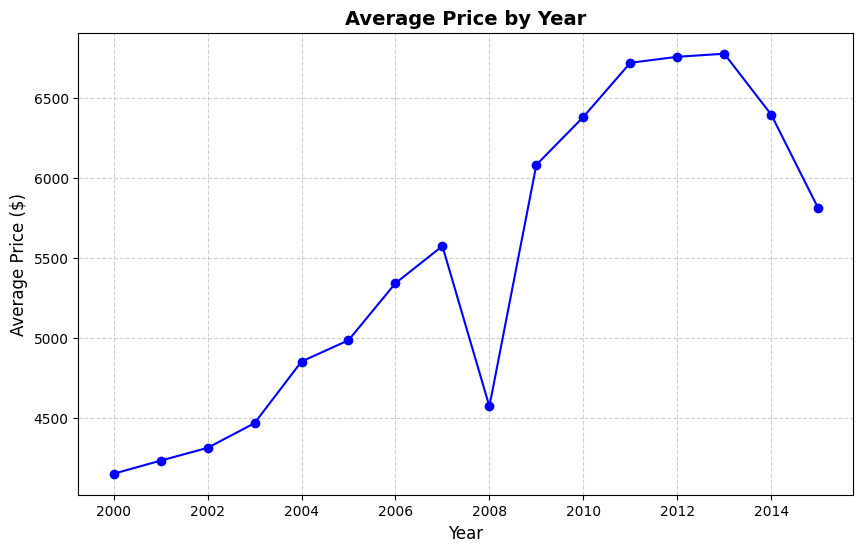

In [33]:
avg_price_by_year = df_clean.groupby("year")["price"].mean().reset_index()
plt.figure(figsize=(10,6))
plt.plot(avg_price_by_year["year"], avg_price_by_year["price"], marker="o", color="b", linestyle="-")
plt.title('Average Price by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

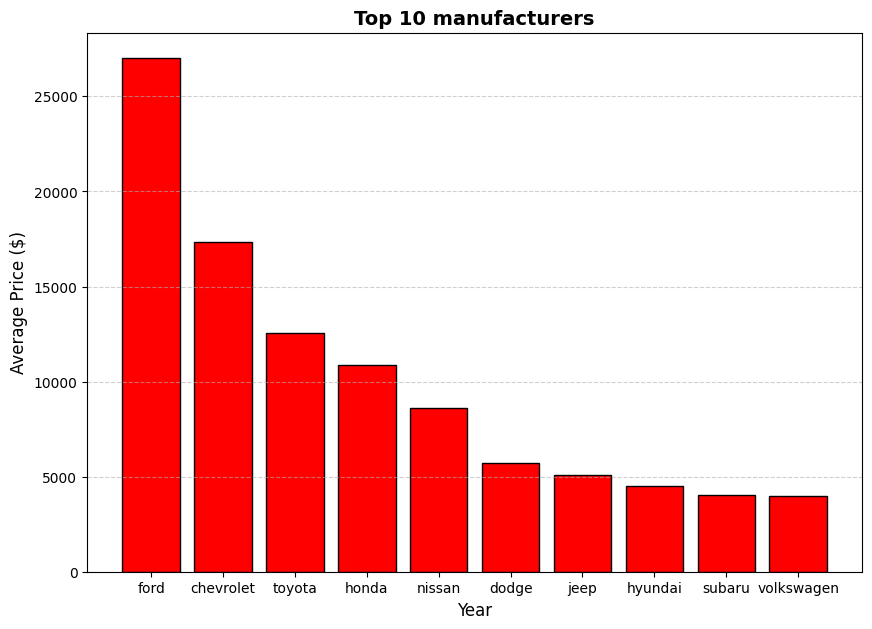

In [34]:
plt.figure(figsize=(10,7))
plt.bar(top_10_manf["manufacturer"],top_10_manf["count"], color="red", edgecolor="black")
plt.title('Top 10 manufacturers', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

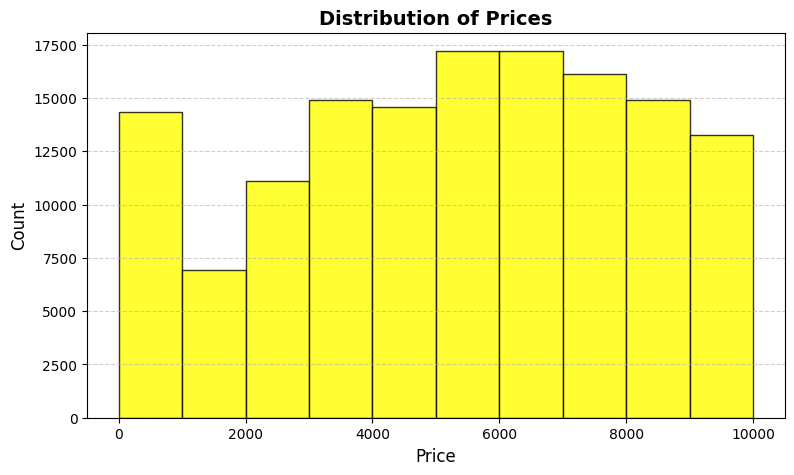

In [56]:
filtered_df = df_clean[df_clean['price'] < 100000]

plt.figure(figsize=(9, 5))
plt.hist(filtered_df['price'], bins=10, color='yellow', edgecolor='black', alpha=0.8)

plt.title('Distribution of Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

/tmp/ipykernel_998/1968425871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel', y='price', data=filtered_df, palette='Set2')


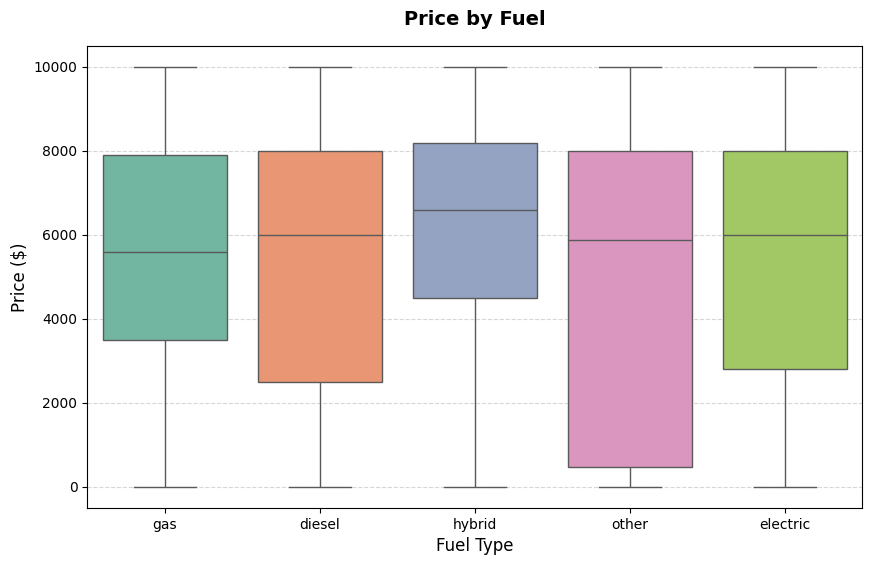

In [51]:
filtered_df = df_clean
plt.figure(figsize=(10, 6))

sns.boxplot(x='fuel', y='price', data=filtered_df, palette='Set2')

plt.title('Price by Fuel', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fuel', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

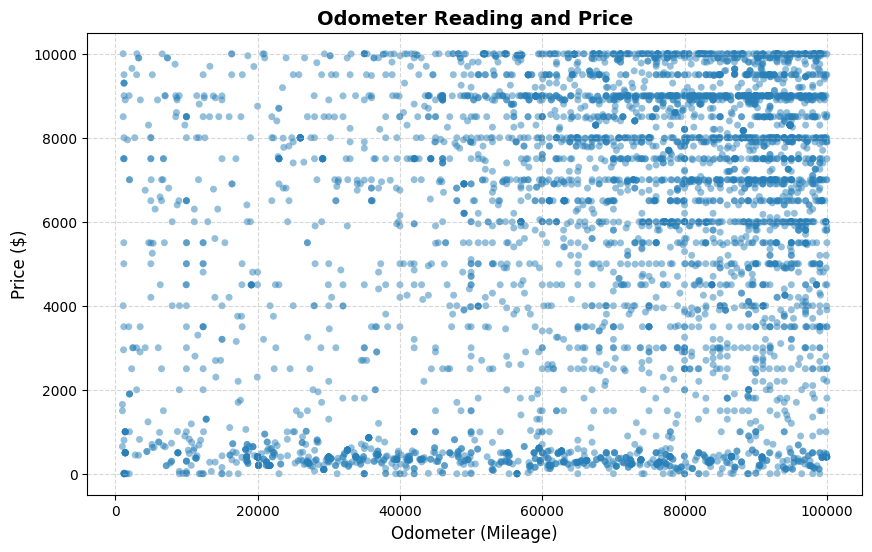

In [45]:
filtered_df = df_clean[(df_clean["odometer"]<100000)&(df_clean["odometer"]>1000)].head(5000)
plt.figure(figsize=(10, 6))
plt.scatter(
    filtered_df['odometer'],
    filtered_df['price'],
    alpha=0.5,
    c='#2980b9',
    edgecolors='none',
    s=25                
)

plt.title('Odometer and Price', fontsize=14, fontweight='bold')
plt.xlabel('Odometer', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

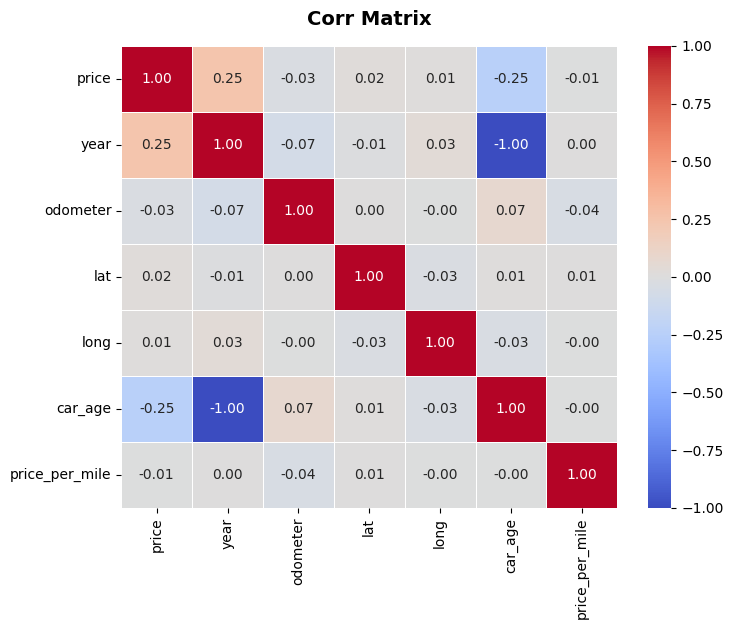

In [47]:
numerical_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Corr Matrix', fontsize=14, fontweight='bold', pad=15)
plt.show()